## Exercise 1.1 — Mass of a 1D Metal Rod

**Problem:** Find the mass of a metal rod:
- Length: **20 cm** (starting at $x = 0$)
- Density function: $\rho(x) = e^{x/2}$ gr/cm³

**Formula:**
$$M = \int_0^{20} \rho(x)\, dx = \int_0^{20} e^{x/2}\, dx$$

**Analytical Solution:**
$$M = \left[2e^{x/2}\right]_0^{20} = 2(e^{10} - 1)$$

**Methods used:** Trapezoidal Rule & Simpson's Rule

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 1. Define the Density Function and Parameters

In [2]:
# Density function
def rho(x):
    """rho(x) = e^(x/2)  [g/cm^3]"""
    return np.exp(0.5 * x)

# Integration limits and step size
a, b = 0, 20       # limits in cm
n    = 1000        # number of sub-intervals (must be even for Simpson's)
h    = (b - a) / n # step size
x    = np.linspace(a, b, n + 1)
y    = rho(x)

print(f'Interval  : [{a}, {b}] cm')
print(f'Intervals : n = {n}')
print(f'Step size : h = {h:.4f} cm')

Interval  : [0, 20] cm
Intervals : n = 1000
Step size : h = 0.0200 cm


## 2. Plot the Density Function

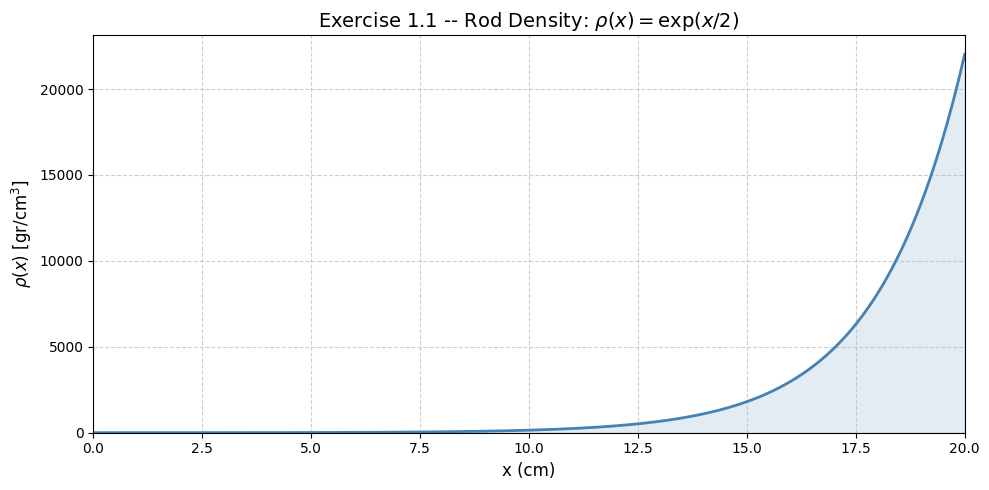

In [3]:
x_plot = np.linspace(a, b, 1000)
y_plot = rho(x_plot)

fig, ax = plt.subplots(figsize=(10, 5))
ax.fill_between(x_plot, y_plot, alpha=0.15, color='steelblue')
ax.plot(x_plot, y_plot, color='steelblue', linewidth=2)
ax.set_title(r'Exercise 1.1 -- Rod Density: $\rho(x) = \exp(x/2)$', fontsize=14)
ax.set_xlabel('x (cm)', fontsize=12)
ax.set_ylabel(r'$\rho(x)$ [gr/cm$^3$]', fontsize=12)
ax.set_xlim(a, b)
ax.set_ylim(bottom=0)
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## 3. Trapezoidal Rule

$$M \approx \frac{h}{2}\left[f(x_0) + 2f(x_1) + 2f(x_2) + \cdots + 2f(x_{n-1}) + f(x_n)\right]$$

In [4]:
mass_trap = h * (0.5 * y[0] + np.sum(y[1:-1]) + 0.5 * y[-1])
print(f'Mass (Trapezoidal Rule) = {mass_trap:,.6f} g')

Mass (Trapezoidal Rule) = 44,051.298680 g


## 4. Simpson's Rule

$$M \approx \frac{h}{3}\left[f(x_0) + 4f(x_1) + 2f(x_2) + 4f(x_3) + \cdots + f(x_n)\right]$$

In [5]:
coeffs = np.ones(n + 1)
coeffs[1:-1:2] = 4   # odd indices  -> coefficient 4
coeffs[2:-2:2] = 2   # even indices -> coefficient 2
mass_simp = (h / 3) * np.dot(coeffs, y)
print(f"Mass (Simpson's Rule) = {mass_simp:,.6f} g")

Mass (Simpson's Rule) = 44,050.931592 g


## 5. Analytical (Exact) Solution

$$M = \int_0^{20} e^{x/2}\, dx = \left[2e^{x/2}\right]_0^{20} = 2(e^{10} - 1)$$

In [6]:
mass_exact = 2 * (math.exp(10) - 1)
print(f'Mass (Exact) = 2(e^10 - 1) = {mass_exact:,.6f} g')

Mass (Exact) = 2(e^10 - 1) = 44,050.931590 g


## 6. Error Estimation

In [7]:
err_trap = abs(mass_exact - mass_trap)
err_simp = abs(mass_exact - mass_simp)
rel_trap = err_trap / mass_exact * 100
rel_simp = err_simp / mass_exact * 100

print('=' * 58)
print('   Results Summary')
print('=' * 58)
print(f'  Exact              : {mass_exact:>16,.6f} g')
print(f'  Trapezoidal Rule   : {mass_trap:>16,.6f} g')
print(f"  Simpson's Rule     : {mass_simp:>16,.6f} g")
print('-' * 58)
print(f'  Error (Trap) abs   : {err_trap:.4e} g   rel: {rel_trap:.4e} %')
print(f"  Error (Simp) abs   : {err_simp:.4e} g   rel: {rel_simp:.4e} %")
print('=' * 58)

   Results Summary
  Exact              :    44,050.931590 g
  Trapezoidal Rule   :    44,051.298680 g
  Simpson's Rule     :    44,050.931592 g
----------------------------------------------------------
  Error (Trap) abs   : 3.6709e-01 g   rel: 8.3333e-04 %
  Error (Simp) abs   : 2.4473e-06 g   rel: 5.5555e-09 %


## 7. Error Comparison Plot

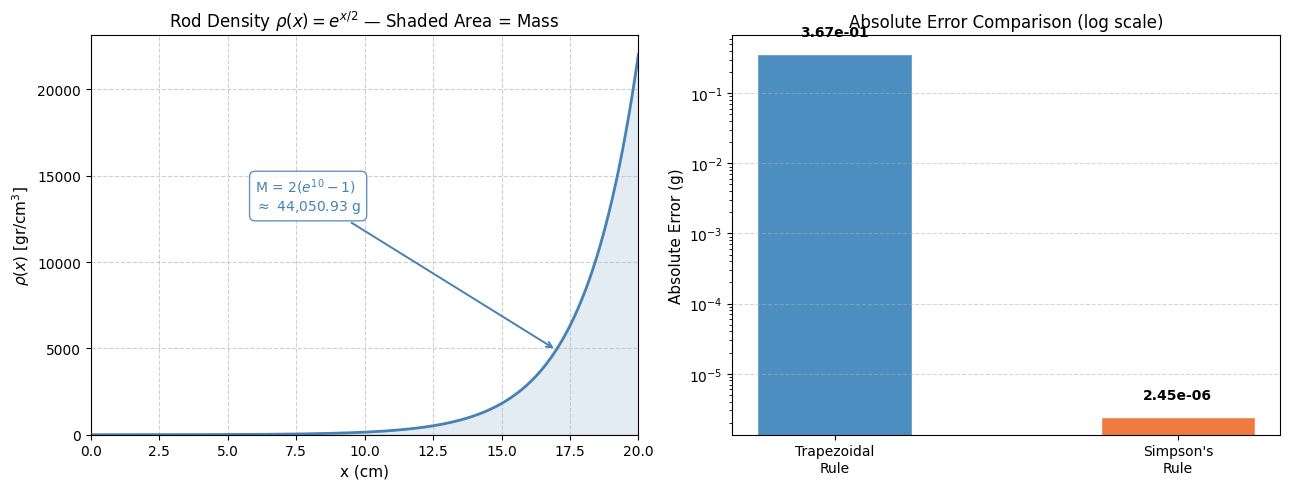


Simpson's Rule is ~150,001x more accurate than the Trapezoidal Rule.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: density curve
ax1 = axes[0]
ax1.fill_between(x_plot, y_plot, alpha=0.15, color='steelblue')
ax1.plot(x_plot, y_plot, color='steelblue', linewidth=2)
ax1.set_title(r'Rod Density $\rho(x) = e^{x/2}$ — Shaded Area = Mass', fontsize=12)
ax1.set_xlabel('x (cm)', fontsize=11)
ax1.set_ylabel(r'$\rho(x)$ [gr/cm$^3$]', fontsize=11)
ax1.set_xlim(a, b)
ax1.set_ylim(bottom=0)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.annotate(
    f'M = $2(e^{{10}}-1)$\n$\\approx$ {mass_exact:,.2f} g',
    xy=(17, rho(17)), xytext=(6, 13000), fontsize=10, color='steelblue',
    arrowprops=dict(arrowstyle='->', color='steelblue', lw=1.4),
    bbox=dict(boxstyle='round,pad=0.4', fc='white', ec='steelblue', alpha=0.85)
)

# Right: error bar chart
ax2 = axes[1]
methods = ['Trapezoidal\nRule', "Simpson's\nRule"]
errors  = [err_trap, err_simp]
colors  = ['#4C8EBF', '#F07B3F']
bars = ax2.bar(methods, errors, color=colors, width=0.45, edgecolor='white')
ax2.set_title('Absolute Error Comparison (log scale)', fontsize=12)
ax2.set_ylabel('Absolute Error (g)', fontsize=11)
ax2.set_yscale('log')
ax2.grid(True, axis='y', linestyle='--', alpha=0.5)
for bar, err in zip(bars, errors):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.8,
             f'{err:.2e}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nSimpson's Rule is ~{err_trap/err_simp:,.0f}x more accurate than the Trapezoidal Rule.")